In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [23]:
dataset=pd.read_csv('slip_24.csv')
X=dataset.iloc[:,1:-1].values
y=dataset.iloc[:,-1].values
print(dataset.isnull().sum())

User ID                       0
Device Model                  0
Operating System              0
App Usage Time (min/day)      0
Screen On Time (hours/day)    0
Battery Drain (mAh/day)       0
Number of Apps Installed      0
Data Usage (MB/day)           0
Age                           0
Gender                        0
User Behavior Class           0
dtype: int64


In [24]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ct=ColumnTransformer(transformers=[('encoder',OneHotEncoder(sparse_output=False),[0,1,8])],remainder="passthrough")
X=ct.fit_transform(X)


In [25]:
print(X)

[[1.0 0.0 0.0 ... 67 1122 40]
 [0.0 1.0 0.0 ... 42 944 47]
 [0.0 0.0 0.0 ... 32 322 42]
 ...
 [1.0 0.0 0.0 ... 22 457 50]
 [0.0 0.0 1.0 ... 13 224 44]
 [0.0 1.0 0.0 ... 49 828 23]]


In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [27]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [31]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix,accuracy_score
kernels=['linear','poly','rbf','sigmoid']
best_acc=0
best_acc_kernel=''
accuracies=[]

for k in kernels:
    print("========================= Kernel : ",k.upper()," =======================")

    s=SVC(kernel=k,random_state=0)
    s.fit(X_train,y_train)

    y_pred=s.predict(X_test)

    c=confusion_matrix(y_test,y_pred)
    print("Confusion matrix : \n ",c)

    acc=accuracy_score(y_test,y_pred)*100
    print("Accuracy : ",round(acc,2))
    accuracies.append(acc)

    if acc>best_acc:
        best_acc=acc
        best_acc_kernel=k

print("\n\nbest kernel : ",best_acc_kernel.upper())
print("Accuracy : ",best_acc)
    

========================= Kernel :  LINEAR  =======================
Confusion matrix : 
  [[23  0  0  0  0]
 [ 0 23  0  0  0]
 [ 0  0 42  0  0]
 [ 0  0  0 26  0]
 [ 0  0  0  0 26]]
Accuracy :  100.0
========================= Kernel :  POLY  =======================
Confusion matrix : 
  [[23  0  0  0  0]
 [ 0 23  0  0  0]
 [ 0  0 42  0  0]
 [ 0  0  0 26  0]
 [ 0  0  0  0 26]]
Accuracy :  100.0
========================= Kernel :  RBF  =======================
Confusion matrix : 
  [[23  0  0  0  0]
 [ 0 23  0  0  0]
 [ 0  0 42  0  0]
 [ 0  0  0 26  0]
 [ 0  0  0  0 26]]
Accuracy :  100.0
========================= Kernel :  SIGMOID  =======================
Confusion matrix : 
  [[20  3  0  0  0]
 [ 2 21  0  0  0]
 [ 0 11 30  1  0]
 [ 0  0  0 25  1]
 [ 0  0  0  2 24]]
Accuracy :  85.71


best kernel :  LINEAR
Accuracy :  100.0


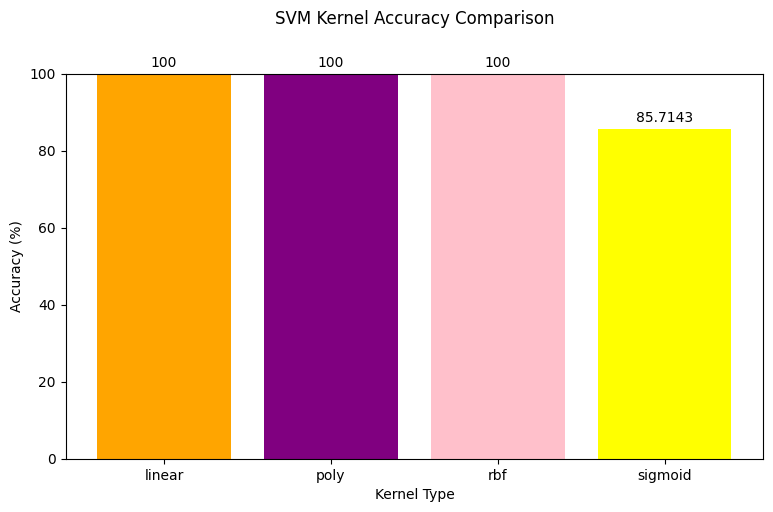

In [29]:
plt.figure(figsize=(9,5))
bars=plt.bar(kernels,accuracies,color=['orange','purple','pink','yellow'])
plt.bar_label(bars,padding=3)
plt.title('SVM Kernel Accuracy Comparison\n\n')
plt.xlabel('Kernel Type')
plt.ylabel('Accuracy (%)')
plt.ylim(0,100)
plt.show()
